<a href="https://colab.research.google.com/github/mipaillafil/Proyecto_Aeropuertos_Cortes_Marchesse_Paillafil/blob/feature%2Fpipeline-etl/ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocesamiento y Limpieza de Datos de Operaciones Aeroportuarias

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

## 2. Carga y Visión General del Dataset

In [2]:
url = "https://raw.githubusercontent.com/mipaillafil/Proyecto_Aeropuertos_Cortes_Marchesse_Paillafil/main/data/operaciones_aeropuertos_dirty.csv"
df = pd.read_csv(url)
display(df.head())

,mes_id,aeropuerto_oaci,internacional_domestico,cnt_operaciones
0,200001.0,SCAP,D,6.0
1,200001.0,SCAR,D,691.0
2,200001.0,SCAR,I,139.0
3,200001.0,SCBA,D,382.0
4,200001.0,SCCC,D,82.0


In [3]:
# Analisis inicial: Mostrar estructura general del dataset
print("Información general del dataset:")
df.info()

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16507 entries, 0 to 16506
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   mes_id                   15712 non-null  object
 1   aeropuerto_oaci          15725 non-null  object
 2   internacional_domestico  15716 non-null  object
 3   cnt_operaciones          15739 non-null  object
dtypes: object(4)
memory usage: 516.0+ KB


In [4]:
# Identificar la cantidad de valores nulos que hay en cada columna
print("Cantidad de valores nulos por columna:")
display(df.isnull().sum())

Cantidad de valores nulos por columna:


,0
mes_id,795
aeropuerto_oaci,782
internacional_domestico,791
cnt_operaciones,768


In [5]:
# Estadisticas descriptivas para detectar posibles outliers en columnas numéricas
print("Estadísticas descriptivas del dataset:")
display(df.describe())

Estadísticas descriptivas del dataset:


,mes_id,aeropuerto_oaci,internacional_domestico,cnt_operaciones
count,15712,15725,15716,15739
unique,604,120,5,3125
top,202412.0,SCEL,D,2.0
freq,67,615,11143,602


## 3. Limpieza Inicial y Preparación de Datos

In [6]:
# Copiar dataset para la limpieza
df_sucio = df.copy()
print("Primeras 5 filas del dataset copiado:")
display(df_sucio.head())

Primeras 5 filas del dataset copiado:


,mes_id,aeropuerto_oaci,internacional_domestico,cnt_operaciones
0,200001.0,SCAP,D,6.0
1,200001.0,SCAR,D,691.0
2,200001.0,SCAR,I,139.0
3,200001.0,SCBA,D,382.0
4,200001.0,SCCC,D,82.0


In [7]:
# Eliminar datos duplicados
df_sucio = df_sucio.drop_duplicates()
print(f"Filas después de eliminar duplicados: {df_sucio.shape[0]}")

Filas después de eliminar duplicados: 15654


In [8]:
# Limpiar espacios en strings de columnas de tipo 'object'
for col in df_sucio.select_dtypes(include=['object']).columns:
    df_sucio[col] = df_sucio[col].str.strip()
print("Espacios en blanco eliminados de columnas categóricas.")

Espacios en blanco eliminados de columnas categóricas.


In [9]:
# Convertir 'cnt_operaciones' a numérico y crear 'total_operaciones'
df_sucio["cnt_operaciones"] = pd.to_numeric(df_sucio["cnt_operaciones"], errors="coerce")
df_sucio["total_operaciones"] = df_sucio["cnt_operaciones"]
print("'cnt_operaciones' convertida a numérico y 'total_operaciones' creada.")

'cnt_operaciones' convertida a numérico y 'total_operaciones' creada.


## 4. Visualización Pre-procesamiento

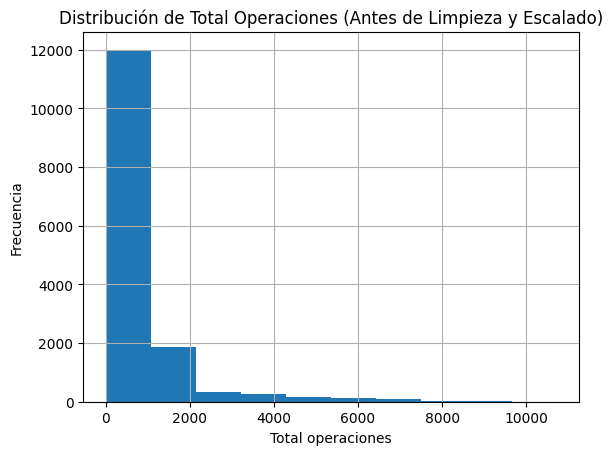

In [10]:
# Visualizar histograma de 'total_operaciones' antes del procesamiento avanzado
df_sucio["total_operaciones"].hist()
plt.title("Distribución de Total Operaciones (Antes de Limpieza y Escalado)")
plt.xlabel("Total operaciones")
plt.ylabel("Frecuencia")
plt.show()

## 5. Definición y Aplicación de Pipelines de Preprocesamiento

In [11]:
# Separar por tipo de variable (después de la conversión a numérico)
num_cols = df_sucio.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_sucio.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas numéricas identificadas: {num_cols}")
print(f"Columnas categóricas identificadas: {cat_cols}")

Columnas numéricas identificadas: ['cnt_operaciones', 'total_operaciones']
Columnas categóricas identificadas: ['mes_id', 'aeropuerto_oaci', 'internacional_domestico']


In [12]:
# Pipeline numérico: Imputación por la media y Escalado estándar
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
print("Pipeline numérico definido.")

Pipeline numérico definido.


In [13]:
# Pipeline categórico: Imputación por la moda y One-Hot Encoding
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
print("Pipeline categórico definido.")

Pipeline categórico definido.


In [14]:
# Definir el preprocesador utilizando ColumnTransformer
preprocesador = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])
print("ColumnTransformer definido.")

ColumnTransformer definido.


In [15]:
# Aplicar pipelines al DataFrame sucio
df_procesado = preprocesador.fit_transform(df_sucio)
print("Pipelines aplicados al dataset.")

Pipelines aplicados al dataset.


In [16]:
# Obtener los nombres de las columnas categóricas transformadas
cat_nombres = preprocesador.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols)
print("Nombres de columnas categóricas transformadas obtenidos.")

Nombres de columnas categóricas transformadas obtenidos.


In [17]:
# Combinar todos los nombres de columnas (numéricas originales + categóricas transformadas)
todas_columnas = num_cols + list(cat_nombres)
print("Nombres de todas las columnas combinados.")

Nombres de todas las columnas combinados.


In [18]:
# Crear el DataFrame limpio a partir de los datos procesados
df_limpio = pd.DataFrame(df_procesado, columns=todas_columnas)
print("DataFrame limpio creado.")
display(df_limpio.head())

DataFrame limpio creado.


,cnt_operaciones,total_operaciones,mes_id_200001.0,mes_id_200002.0,mes_id_200003.0,mes_id_200004.0,mes_id_200005.0,mes_id_200006.0,mes_id_200007.0,mes_id_200008.0,...,aeropuerto_oaci_SCVD,aeropuerto_oaci_SCVH,aeropuerto_oaci_SCVI,aeropuerto_oaci_SCVL,aeropuerto_oaci_SCVM,aeropuerto_oaci_SCVV,aeropuerto_oaci_nan,internacional_domestico_D,internacional_domestico_I,internacional_domestico_nan
0,-0.555716,-0.555716,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.029270,0.029270,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.442135,-0.442135,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.234614,-0.234614,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.490812,-0.490812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 6. Detección y Eliminación de Outliers

In [19]:
# Detección de outliers usando el método IQR en 'total_operaciones'
Q1 = df_limpio["total_operaciones"].quantile(0.25)
Q3 = df_limpio["total_operaciones"].quantile(0.75)
IQR = Q3 - Q1

# Filtrar outliers
df_limpio_filtered = df_limpio[
    (df_limpio["total_operaciones"] >= (Q1 - 1.5 * IQR)) &
    (df_limpio["total_operaciones"] <= (Q3 + 1.5 * IQR))
]

print(f"Filas antes de detección de outliers: {df_limpio.shape[0]}")
print(f"Filas después de detección de outliers: {df_limpio_filtered.shape[0]}")
df_limpio = df_limpio_filtered.copy()

Filas antes de detección de outliers: 15654
Filas después de detección de outliers: 14398


## 7. Visualización Post-procesamiento

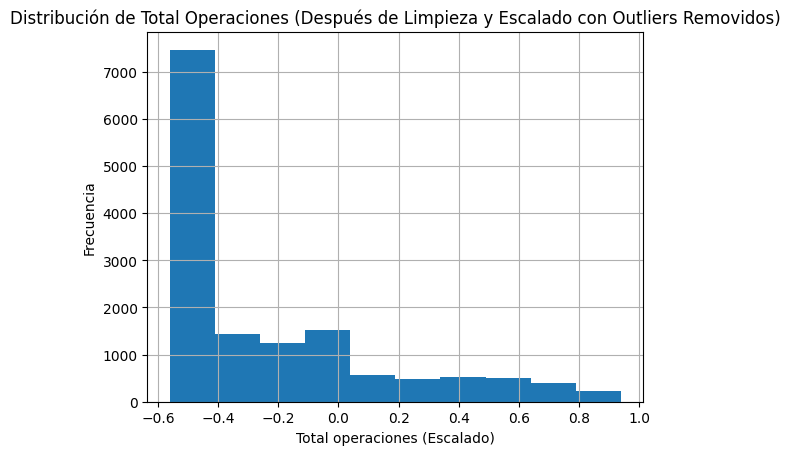

In [20]:
# Visualizar histograma de 'total_operaciones' después de la limpieza y detección de outliers
df_limpio["total_operaciones"].hist()
plt.title("Distribución de Total Operaciones (Después de Limpieza y Escalado con Outliers Removidos)")
plt.xlabel("Total operaciones (Escalado)")
plt.ylabel("Frecuencia")
plt.show()

##8. Exportar y descargar


In [23]:
from google.colab import files
df_limpio.to_csv("operaciones_aeropuertos_clean.csv", index=False)

files.download(
    "operaciones_aeropuertos_clean.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Verificación del Archivo Exportado

In [22]:
try:
    df_verificacion = pd.read_csv("operaciones_aeropuertos_clean.csv")
    print("Archivo 'operaciones_aeropuertos_clean.csv' cargado correctamente.")
    display(df_verificacion.head())
except FileNotFoundError:
    print("Error: El archivo 'operaciones_aeropuertos_clean.csv' no se encuentra.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Archivo 'operaciones_aeropuertos_clean.csv' cargado correctamente.


,cnt_operaciones,total_operaciones,mes_id_200001.0,mes_id_200002.0,mes_id_200003.0,mes_id_200004.0,mes_id_200005.0,mes_id_200006.0,mes_id_200007.0,mes_id_200008.0,...,aeropuerto_oaci_SCVD,aeropuerto_oaci_SCVH,aeropuerto_oaci_SCVI,aeropuerto_oaci_SCVL,aeropuerto_oaci_SCVM,aeropuerto_oaci_SCVV,aeropuerto_oaci_nan,internacional_domestico_D,internacional_domestico_I,internacional_domestico_nan
0,-0.555716,-0.555716,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.029270,0.029270,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.442135,-0.442135,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.234614,-0.234614,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.490812,-0.490812,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
